---
# <font color="#CA3532">Deep Learning Fundamentals and Basic Tools (2026/2027) - Final project</font>
---


In this project you will implement and compare four deep-learning architectures for multiclass human activity recognition:

- Deep Neural Network (DNN)
- Recurrent Neural Network (RNN)
- 1D Convolutional Neural Network (CNN)
- Long Short-Term Memory Network (LSTM)

You will work with the **UCI Human Activity Recognition Using Smartphones (UCI HAR)** dataset.

You must compare predictive performance, class-level errors, convergence, model complexity, training time, inference time, and stability across repeated runs.

## <font color="#3279ca">Generative-AI Policy</font>


The use of any generative-AI or Large Language Model (LLM) to generate, complete, rewrite, or substantially assist with the code, experiments, analysis, or written answers for this project is **not permitted**.

**Work generated using LLM assistance will be treated as plagiarism. If it is the case, the corresponding project code will not be evaluated and the student will receive no credit for that work.**


## <font color="#3279ca">Project report</font>

You must write a project report explaning the following points;

- individual functions and model layers;
- tensor dimensions;
- the training procedure;
- suugest an alternative for part of your implementation;
- interpret results, confusion matrices, and all metrics;
- explain your conclusions.

Do not submit code or analysis that you cannot explain.

### <font color="#0da432">Imports</font>

In [18]:

import json
import sys
import importlib

if "src.models" in sys.modules:
    del sys.modules["src.models"]

import src.models
importlib.reload(src.models)
import time
import platform

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

import torch
from src.models import (
    DNNClassifier,
    RNNClassifier,
    CNNClassifier,
    LSTMClassifier,
)
from src.training import fit
from src.evaluation import (
    evaluate_model,
    count_parameters,
    measure_inference_time,
)

### <font color="#0da432">Dataset</font>

In [24]:
train_df = pd.read_csv("../data/final_project/train.csv")
test_df = pd.read_csv("../data/final_project/test.csv")

TARGET = "Activity"
DROP_COLUMNS = ["subject", TARGET]

X_train = train_df.drop(columns=DROP_COLUMNS).to_numpy(dtype=np.float32)
X_test = test_df.drop(columns=DROP_COLUMNS).to_numpy(dtype=np.float32)

label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(train_df[TARGET]).astype(np.int64)
y_test = label_encoder.transform(test_df[TARGET]).astype(np.int64)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_test = scaler.transform(X_test).astype(np.float32)

# DNN
X_train_dnn = X_train
X_test_dnn = X_test

# RNN / LSTM
# Shape: (samples, sequence_length, features_per_step)
X_train_rnn = X_train[..., np.newaxis]
X_test_rnn = X_test[..., np.newaxis]

X_train_lstm = X_train[..., np.newaxis]
X_test_lstm = X_test[..., np.newaxis]

# CNN - TensorFlow / Keras Conv1D
# Shape: (samples, length, channels)
X_train_cnn_tf = X_train[..., np.newaxis]
X_test_cnn_tf = X_test[..., np.newaxis]

# CNN - PyTorch Conv1d
# Shape: (samples, channels, length)
X_train_cnn_torch = X_train[:, np.newaxis, :]
X_test_cnn_torch = X_test[:, np.newaxis, :]

n_features = X_train.shape[1]
n_classes = len(label_encoder.classes_)


### <font color="#0da432">Visualize Raw Sequential Sensor Data</font>

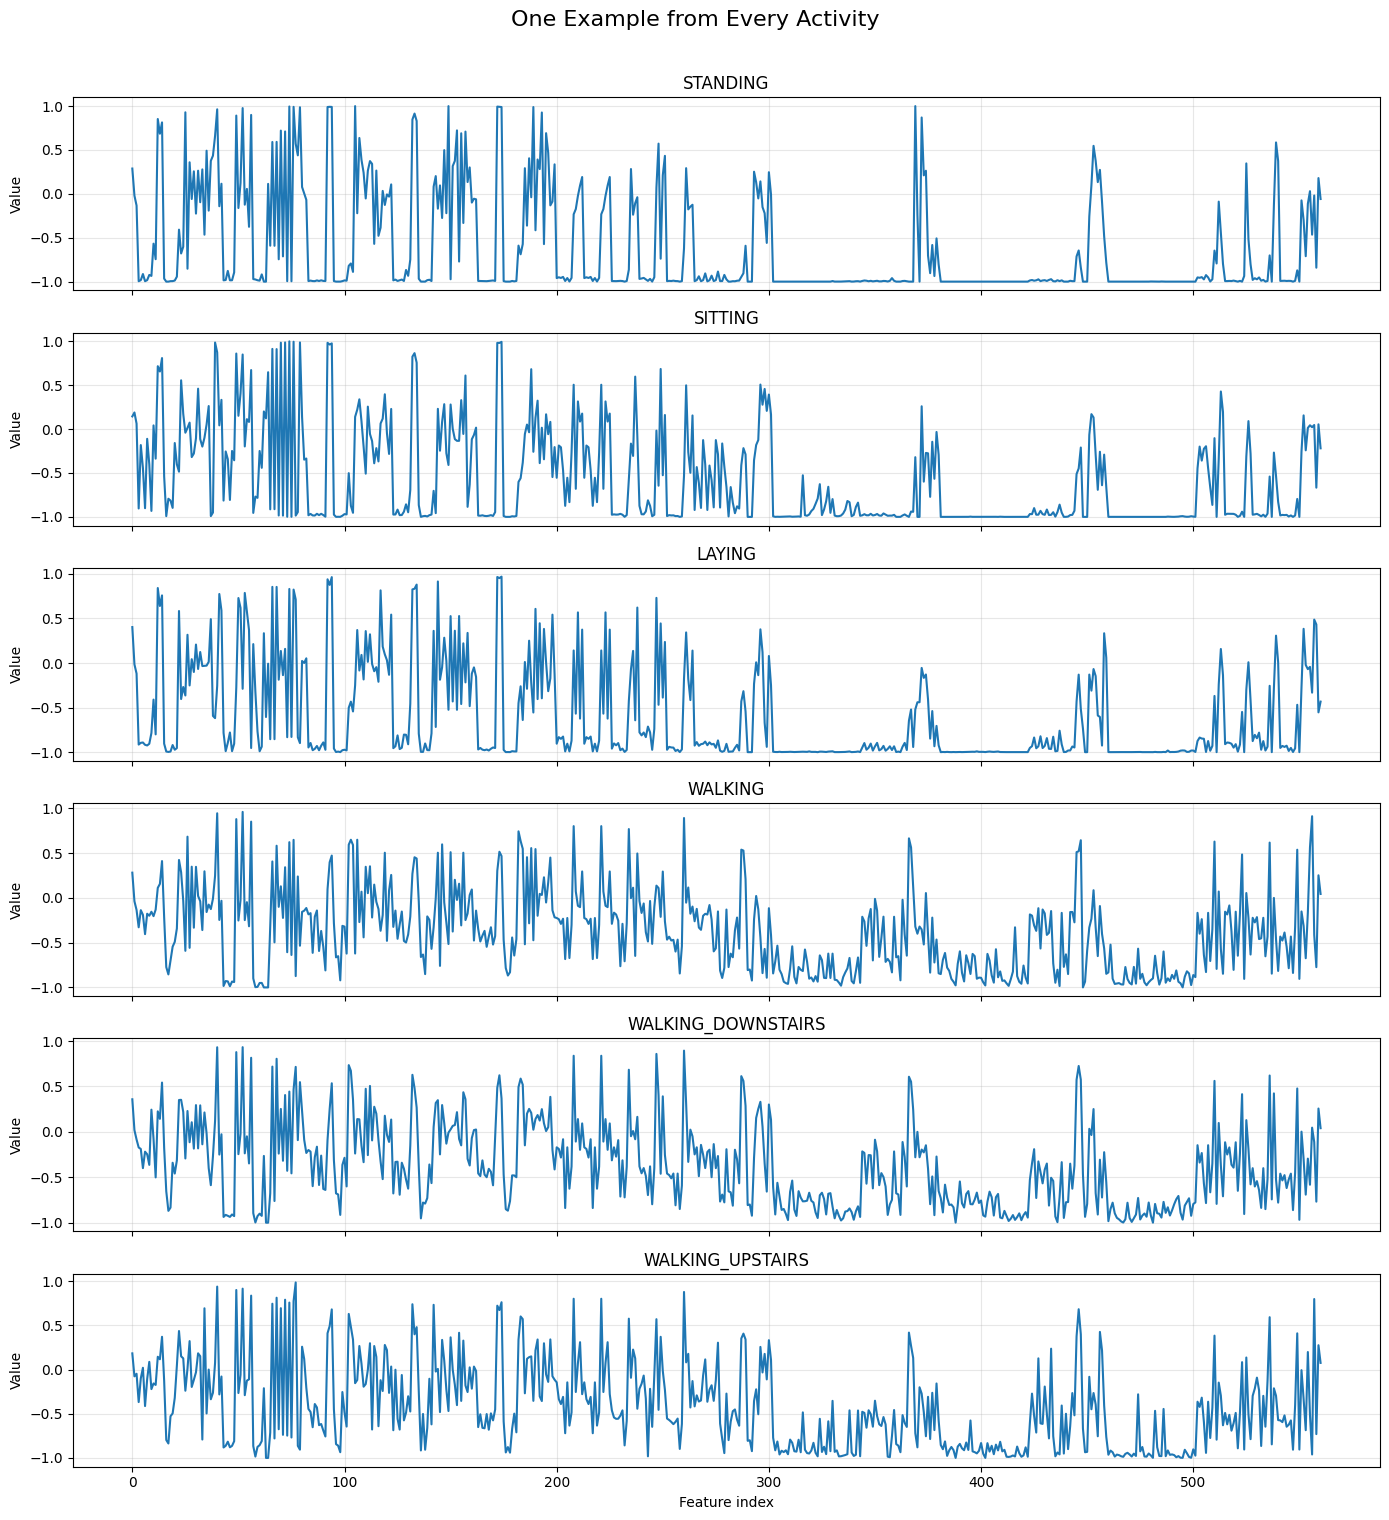

In [25]:
TARGET = "Activity"
FEATURE_COLUMNS = [
    col for col in train_df.columns
    if col not in ["subject", TARGET]
]

activities = train_df[TARGET].unique()

fig, axes = plt.subplots(
    len(activities),
    1,
    figsize=(14, 2.5 * len(activities)),
    sharex=True
)

for ax, activity in zip(axes, activities):

    sample = (
        train_df.loc[
            train_df[TARGET] == activity,
            FEATURE_COLUMNS
        ]
        .iloc[0]
        .to_numpy(dtype=np.float32)
    )

    ax.plot(sample)
    ax.set_title(activity)
    ax.set_ylabel("Value")
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Feature index")

fig.suptitle(
    "One Example from Every Activity",
    fontsize=16,
    y=1.01
)

plt.tight_layout()
plt.show()

### <font color="#0da432">Visualize Raw Sequential Sensor Data</font>

## <font color="#0da432">Implementation Requirements</font>
rgb(18, 13, 164)
You must implement the backend yourself.

Required files:

```text
src/models.py
src/training.py
src/evaluation.py
```

## `src/models.py`

Implement:

```python
DNNClassifier
RNNClassifier
CNNClassifier
LSTMClassifier
```

All models receive the same underlying information and must ultimately output:

```text
(batch_size, 6)
```

logits/scores.

### DNN

Transform:

```text
(batch, 128, 9)
```

into an appropriate vector representation.

### RNN

Process the 128 time steps sequentially with a vanilla recurrent architecture.

### CNN

Use one-dimensional convolution over the temporal dimension.

### LSTM

Use an LSTM-based sequence representation for classification.

Important architectural parameters should be configurable.

##  `src/training.py`

Implement:

```python
fit(
    model,
    X_train,
    y_train,
    X_val,
    y_val,
    **kwargs
)
```

It must return at least:

```python
{
    "model": ...,
    "history": {
        "train_loss": ...,
        "val_loss": ...,
        "train_accuracy": ...,
        "val_accuracy": ...
    },
    "training_time": ...,
    "epochs_completed": ...
}
```

Support appropriate training settings including epochs, batch size, learning rate, seed, device, and early stopping.

##  `src/evaluation.py`

Implement:

```python
evaluate_model(model, X, y, **kwargs)
count_parameters(model)
measure_inference_time(model, X, **kwargs)
```

`evaluate_model` must return at least:

```python
{
    "accuracy": ...,
    "macro_precision": ...,
    "macro_recall": ...,
    "macro_f1": ...,
    "weighted_f1": ...,
    "predictions": ...
}
```

##  `src/utils.py`

Implement:

```python
set_seed(seed)
```

The function must set the relevant random seeds for reproducibility.

# Instantiate DNN, RNN, CNN and LSTM

You may add additional keyword arguments supported by your implementation.

Document your final architecture choices.

In [1]:
SEED = 42
set_seed(SEED)

dnn_model = DNNClassifier(
    sequence_length=sequence_length,
    n_features=n_features,
    n_classes=n_classes,
)

rnn_model = RNNClassifier(
    input_size=n_features,
    n_classes=n_classes,
)

cnn_model = CNNClassifier(
    input_size=n_features,
    n_classes=n_classes,
)

lstm_model = LSTMClassifier(
    input_size=n_features,
    n_classes=n_classes,
)

models = {
    "DNN": dnn_model,
    "RNN": rnn_model,
    "CNN": cnn_model,
    "LSTM": lstm_model,
}

NameError: name 'set_seed' is not defined

# Forward-Pass

In [ ]:
sample_batch = torch.tensor(
    X_train[:8],
    dtype=torch.float32,
)

for name, model in models.items():
    model.eval()

    with torch.no_grad():
        output = model(sample_batch)

    print(
        f"{name:5s} | "
        f"input={tuple(sample_batch.shape)} | "
        f"output={tuple(output.shape)}"
    )

    assert output.shape == (8, n_classes)

### Architecture documentation

For each architecture document:

- input representation;
- layer structure;
- hidden/filter dimensions;
- activation functions;
- dropout;
- output representation;
- parameter choices;
- what temporal information the architecture can exploit.

**TODO:** Write your architecture documentation in the project report.

# Training

Use comparable conditions.

Do not use the test set for model selection or hyperparameter tuning.

In [ ]:
TRAINING_CONFIG = {
    "epochs": 50,
    "batch_size": 64,
    "learning_rate": 1e-3,
    "patience": 8,
    "seed": SEED,
}

TRAINING_CONFIG

# Train DNN

In [ ]:
dnn_result = fit(
    dnn_model,
    X_train, y_train,
    X_val, y_val,
    **TRAINING_CONFIG,
)

dnn_model = dnn_result["model"]

print("Training time:", dnn_result["training_time"])
print("Epochs:", dnn_result["epochs_completed"])

# Train RNN

In [ ]:
rnn_result = fit(
    rnn_model,
    X_train, y_train,
    X_val, y_val,
    **TRAINING_CONFIG,
)

rnn_model = rnn_result["model"]

print("Training time:", rnn_result["training_time"])
print("Epochs:", rnn_result["epochs_completed"])

# Train CNN

In [ ]:
cnn_result = fit(
    cnn_model,
    X_train, y_train,
    X_val, y_val,
    **TRAINING_CONFIG,
)

cnn_model = cnn_result["model"]

print("Training time:", cnn_result["training_time"])
print("Epochs:", cnn_result["epochs_completed"])

# Train LSTM

In [ ]:
lstm_result = fit(
    lstm_model,
    X_train, y_train,
    X_val, y_val,
    **TRAINING_CONFIG,
)

lstm_model = lstm_result["model"]

print("Training time:", lstm_result["training_time"])
print("Epochs:", lstm_result["epochs_completed"])

# Collect Training Results

In [ ]:
training_results = {
    "DNN": dnn_result,
    "RNN": rnn_result,
    "CNN": cnn_result,
    "LSTM": lstm_result,
}

trained_models = {
    name: result["model"]
    for name, result in training_results.items()
}

# Loss Curves

In [ ]:
for name, result in training_results.items():
    history = result["history"]

    plt.figure(figsize=(8, 4))
    plt.plot(history["train_loss"], label="Training")
    plt.plot(history["val_loss"], label="Validation")
    plt.title(f"{name}: Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

#  Accuracy Curves

In [ ]:
for name, result in training_results.items():
    history = result["history"]

    plt.figure(figsize=(8, 4))
    plt.plot(history["train_accuracy"], label="Training")
    plt.plot(history["val_accuracy"], label="Validation")
    plt.title(f"{name}: Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.show()

### Training behavior analysis

For each architecture explain:

- convergence speed;
- overfitting;
- underfitting;
- stability;
- early stopping;
- train/validation gap.

**TODO:** Write add your analysis in ypur report.

# Final Test Evaluation



Report:

- Accuracy
- Macro Precision
- Macro Recall
- Macro F1
- Weighted F1
- Per-class metrics

In [ ]:
test_results = {}

for name, model in trained_models.items():
    test_results[name] = evaluate_model(
        model,
        X_test,
        y_test,
    )

comparison_df = pd.DataFrame([
    {
        "Model": name,
        "Accuracy": result["accuracy"],
        "Macro Precision": result["macro_precision"],
        "Macro Recall": result["macro_recall"],
        "Macro F1": result["macro_f1"],
        "Weighted F1": result["weighted_f1"],
    }
    for name, result in test_results.items()
])

comparison_df

# Per-Class Classification Reports

In [ ]:
for name, result in test_results.items():
    print("\n" + "=" * 80)
    print(name)
    print("=" * 80)

    print(
        classification_report(
            y_test,
            result["predictions"],
            target_names=class_names,
            digits=4,
        )
    )

# Confusion Matrices

In [ ]:
for name, result in test_results.items():
    cm = confusion_matrix(
        y_test,
        result["predictions"],
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names,
    )

    fig, ax = plt.subplots(figsize=(9, 8))
    disp.plot(ax=ax, xticks_rotation=45)
    plt.title(f"{name}: Confusion Matrix")
    plt.tight_layout()
    plt.show()

### Activity-specific error analysis

Explain in ypur report:

- whether recurrent models make similar errors.
- whether CNN differs from RNN/LSTM.
- whether flattening disadvantages the DNN.


# Trainable Parameter Counts

In [ ]:
parameter_counts = {
    name: count_parameters(model)
    for name, model in trained_models.items()
}

parameter_df = pd.DataFrame({
    "Model": list(parameter_counts.keys()),
    "Parameters": list(parameter_counts.values()),
})

parameter_df

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(parameter_df["Model"], parameter_df["Parameters"])
plt.title("Trainable Parameters")
plt.xlabel("Model")
plt.ylabel("Number of Parameters")
plt.tight_layout()
plt.show()

# Training-Time Comparison

In [ ]:
training_time_df = pd.DataFrame([
    {
        "Model": name,
        "Training Time": result["training_time"],
        "Epochs": result["epochs_completed"],
        "Average Time / Epoch": (
            result["training_time"] /
            max(result["epochs_completed"], 1)
        ),
    }
    for name, result in training_results.items()
])

training_time_df

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(
    training_time_df["Model"],
    training_time_df["Training Time"],
)
plt.title("Total Training Time")
plt.xlabel("Model")
plt.ylabel("Time")
plt.tight_layout()
plt.show()

# Inference-Time Comparison

In [ ]:
inference_times = {
    name: measure_inference_time(model, X_test)
    for name, model in trained_models.items()
}

inference_df = pd.DataFrame({
    "Model": list(inference_times.keys()),
    "Inference Time": list(inference_times.values()),
})

inference_df

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(
    inference_df["Model"],
    inference_df["Inference Time"],
)
plt.title("Inference Time")
plt.xlabel("Model")
plt.ylabel("Time")
plt.tight_layout()
plt.show()

# Complete Model Comparison

In [ ]:
final_comparison = comparison_df.copy()

final_comparison["Parameters"] = (
    final_comparison["Model"].map(parameter_counts)
)

final_comparison["Training Time"] = (
    final_comparison["Model"].map({
        name: result["training_time"]
        for name, result in training_results.items()
    })
)

final_comparison["Inference Time"] = (
    final_comparison["Model"].map(inference_times)
)

final_comparison

# Predictive-Metric Comparison

In [ ]:
metric_columns = [
    "Accuracy",
    "Macro Precision",
    "Macro Recall",
    "Macro F1",
    "Weighted F1",
]

final_comparison.set_index("Model")[metric_columns].plot(
    kind="bar",
    figsize=(12, 6),
)

plt.title("Predictive Performance")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Performance vs Computational Cost

In [ ]:
plt.figure(figsize=(8, 6))

for _, row in final_comparison.iterrows():
    plt.scatter(
        row["Training Time"],
        row["Macro F1"],
        s=100,
    )
    plt.annotate(
        row["Model"],
        (row["Training Time"], row["Macro F1"]),
    )

plt.xlabel("Training Time")
plt.ylabel("Macro F1")
plt.title("Macro F1 vs Training Time")
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(8, 6))

for _, row in final_comparison.iterrows():
    plt.scatter(
        row["Parameters"],
        row["Macro F1"],
        s=100,
    )
    plt.annotate(
        row["Model"],
        (row["Parameters"], row["Macro F1"]),
    )

plt.xlabel("Trainable Parameters")
plt.ylabel("Macro F1")
plt.title("Macro F1 vs Model Size")
plt.tight_layout()
plt.show()

### Performance/cost discussion

Does increased architectural complexity produce a meaningful performance improvement relative to its computational cost?

**TODO:** Add your analysis in your report.

# Repeated Experiments: Three Random Seeds

Run the main comparison with at least:

```python
SEEDS = [1, 42, 123]
```

Instantiate a **new model** for every run.

Do not reuse previously trained weights.

In [ ]:
SEEDS = [1, 42, 123]

seed_experiment_results = []

# TODO:
#
# for seed in SEEDS:
#     1. set_seed(seed)
#     2. instantiate fresh DNN/RNN/CNN/LSTM objects
#     3. train each model
#     4. evaluate it
#     5. record:
#        - Seed
#        - Model
#        - Accuracy
#        - Macro F1
#        - Weighted F1
#        - Training Time
#        - Parameters
#



# Aggregate Repeated Runs

In [ ]:
seed_df = pd.DataFrame(seed_experiment_results)
seed_df

In [ ]:
if not seed_df.empty:
    seed_summary = (
        seed_df
        .groupby("Model")
        .agg({
            "Accuracy": ["mean", "std"],
            "Macro F1": ["mean", "std"],
            "Weighted F1": ["mean", "std"],
            "Training Time": ["mean", "std"],
        })
    )

    display(seed_summary)
else:
    print("Complete the repeated-seed experiment first.")

### Discuss


- variability across seeds.
- whether architecture comparisons remain consistent.
- whether a conclusion based on only one run would be reliable.

**TODO:** Enrich your report.

#  Hyperparameter Experiment

Perform at least one of the following experiment.

Examples:

- DNN hidden dimension or dropout;
- RNN hidden size;
- CNN kernel size;
- CNN filter count;
- LSTM hidden size;
- batch size;
- learning rate.

Change one factor and keep other important conditions fixed.

In [ ]:
experiment_values = [32, 64, 128, 256]
controlled_experiment_results = []

for value in experiment_values:
    # TODO:
    # - instantiate a fresh selected model
    # - use `value` for the selected hyperparameter
    # - train
    # - evaluate
    # - record predictive metrics, time and parameters
    pass

controlled_df = pd.DataFrame(controlled_experiment_results)
controlled_df

### Controlled-experiment discussion

Explain:

- the parameter selected.
- why it was selected.
- effect on predictive performance.
- effect on computational cost.
- whether larger/more complex settings consistently improved generalization.

**TODO:** Make your report count!

# Save Experimental Results

In [ ]:
metrics_dir = PROJECT_ROOT / "results" / "metrics"
figures_dir = PROJECT_ROOT / "results" / "figures"
models_dir = PROJECT_ROOT / "results" / "models"

metrics_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)
models_dir.mkdir(parents=True, exist_ok=True)

final_comparison.to_csv(
    metrics_dir / "model_comparison.csv",
    index=False,
)

if "seed_df" in globals() and not seed_df.empty:
    seed_df.to_csv(
        metrics_dir / "seed_results.csv",
        index=False,
    )

if "controlled_df" in globals() and not controlled_df.empty:
    controlled_df.to_csv(
        metrics_dir / "controlled_experiment.csv",
        index=False,
    )